In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi

0.007539999999999999
mortality increase due to covid: 6.071235286747902
0.9223392932609975
Loss of:  0.0379645220714981
deaths 0.0776607067390025


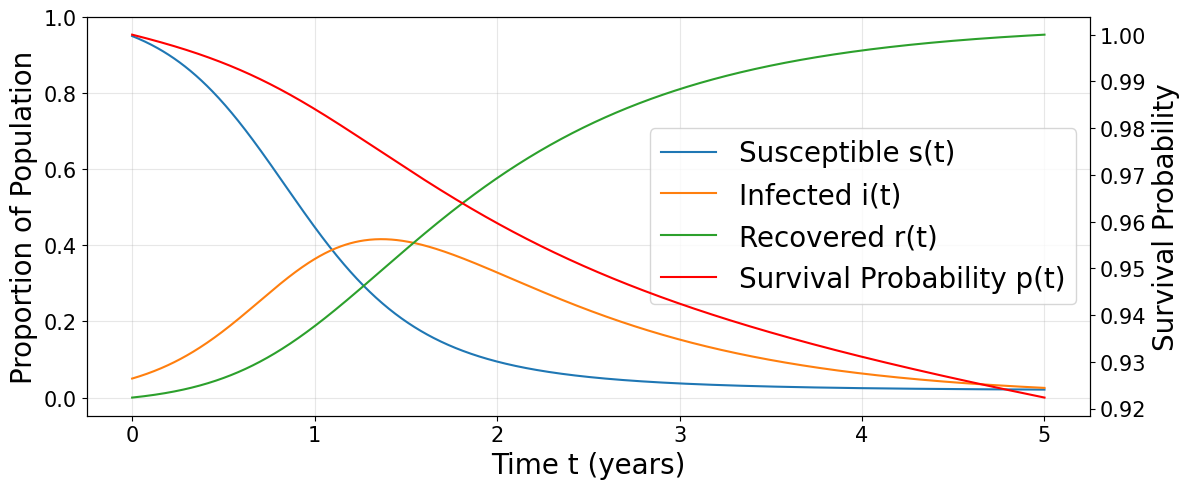

In [2]:
mu = np.mean([7.4, 7.4, 7.6, 7.7, 7.6])/1000 #average 2015-2019 mortality rate (statscan)
print(mu)


DB = 1
P = mu*DB
# mu * (1 + mort_factor) = case fatality rate + general mortality
IFR = 0.15 / 100 # estimated 0.15% 
IFRPerYear = 1 - (1-IFR)**(36.5) #cases last ~10 days on average, do a little math to get yearly survival equiv
mort_factor = IFRPerYear/mu -1 
print("mortality increase due to covid:",mort_factor)
mort_factor = 6
delta = 0.05 # force of interest
ddt = lambda p,t: np.array([-mu*p[0], mu*p[0]])
ic = np.array([0.95,0.05,0,1,0]) # S,I,R,Alive, dead
R0 = 4 #estimate of R0 in Canada at initial outbreak
def ddt(u,t):
    dudt = np.zeros(5)
    dudt[0] = -R0 * u[0]*u[1]
    dudt[1] = R0*u[0] * u[1] - u[1]
    dudt[2] = u[1]
    dudt[3] = -mu*(1+mort_factor*u[1])*u[3]
    dudt[4] = mu*(1+mort_factor*u[1])*u[3]
    return dudt
    

t = np.linspace(0,5,1000)
y0 = spi.odeint(ddt, ic, t)

alive_pandemic = y0[:,3]

# plt.plot(t, y0[:,0:4])
# plt.show()
print(y0[999,3])
tpx = y0[:,3]
mu_xt = mu*(1+mort_factor*y0[:,1])
discount = np.exp(-delta *t)
integrand_ben = DB* tpx * mu_xt *discount
integrand_prem = P * tpx * discount
EPV_ben = spi.trapezoid(integrand_ben,t)
EPV_prem = spi.trapezoid(integrand_prem,t)
#print(EPV_ben)
#print(EPV_prem)
print("Loss of: ", EPV_ben - EPV_prem)
print("deaths", 1- y0[-1,3])

fig, ax1 = plt.subplots(figsize=(12,5))

ax1.set_xlabel("Time t (years)",fontsize=20)
ax1.set_ylabel("Proportion of Population",fontsize=20)
ax1.plot(t,y0[:,0], label="Susceptible s(t)")
ax1.plot(t, y0[:,1], label="Infected i(t)")
ax1.plot(t,y0[:,2], label="Recovered r(t)")
ax1.tick_params(axis='y',labelsize=15)
ax1.tick_params(axis='x',labelsize=15)

#plt.figure(figsize=(12,5))

ax2 = ax1.twinx()

ax2.set_ylabel("Survival Probability",fontsize=20)
ax2.plot(t, y0[:,3], label="Survival Probability p(t)", color="red")
ax2.tick_params(axis='y',labelsize=15)
# plt.plot(t, y0[:,0], label="Susceptible s(t)")
# plt.plot(t, y0[:,1], label="Infected i(t)")
# plt.plot(t, y0[:,2], label="Recovered r(t)")
# plt.plot(t, y0[:,3], label="Survival Probability p(t)")
fig.tight_layout()
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()


combined_lines = lines_1 + lines_2
combined_labels = labels_1 + labels_2

ax1.legend(combined_lines, combined_labels, loc='best',fontsize=20)

# plt.xlabel("Time t (years)")
# plt.ylabel("Proportion")
#plt.legend(loc="best")
ax1.grid(True, alpha=0.3)
# plt.tight_layout()

fig.savefig("SIR&Mort.pdf")
plt.show()

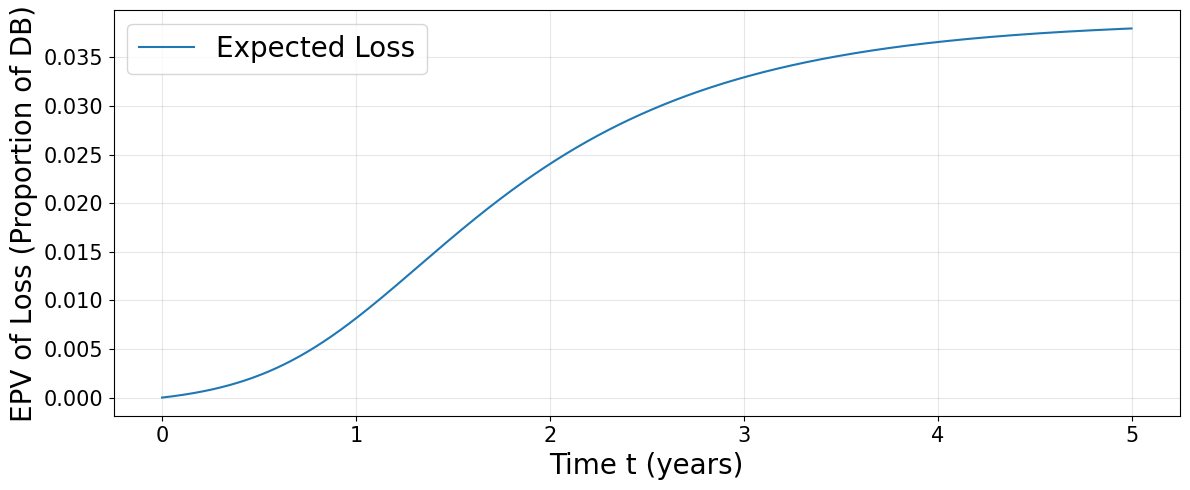

In [6]:
EPV_ben = spi.cumulative_trapezoid(integrand_ben,t, initial = 0)
EPV_prem = spi.cumulative_trapezoid(integrand_prem,t, initial = 0)

Loss_T = EPV_ben - EPV_prem  

plt.figure(figsize=(12,5))
plt.plot(t, Loss_T, label="Expected Loss")
plt.tick_params(axis='y',labelsize=15)
plt.tick_params(axis='x',labelsize=15)

plt.xlabel("Time t (years)",fontsize=20)
plt.ylabel("EPV of Loss (Proportion of DB)",fontsize=20)
#plt.title("Expected Present Value of Loss over Time")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=20,loc="best")
plt.tight_layout()
plt.savefig("EPV_Loss.pdf")

/tmp/ipykernel_15476/2085449718.py:65: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_zticklabels(ax1.get_zticks(), fontdict={'ha':'left'})


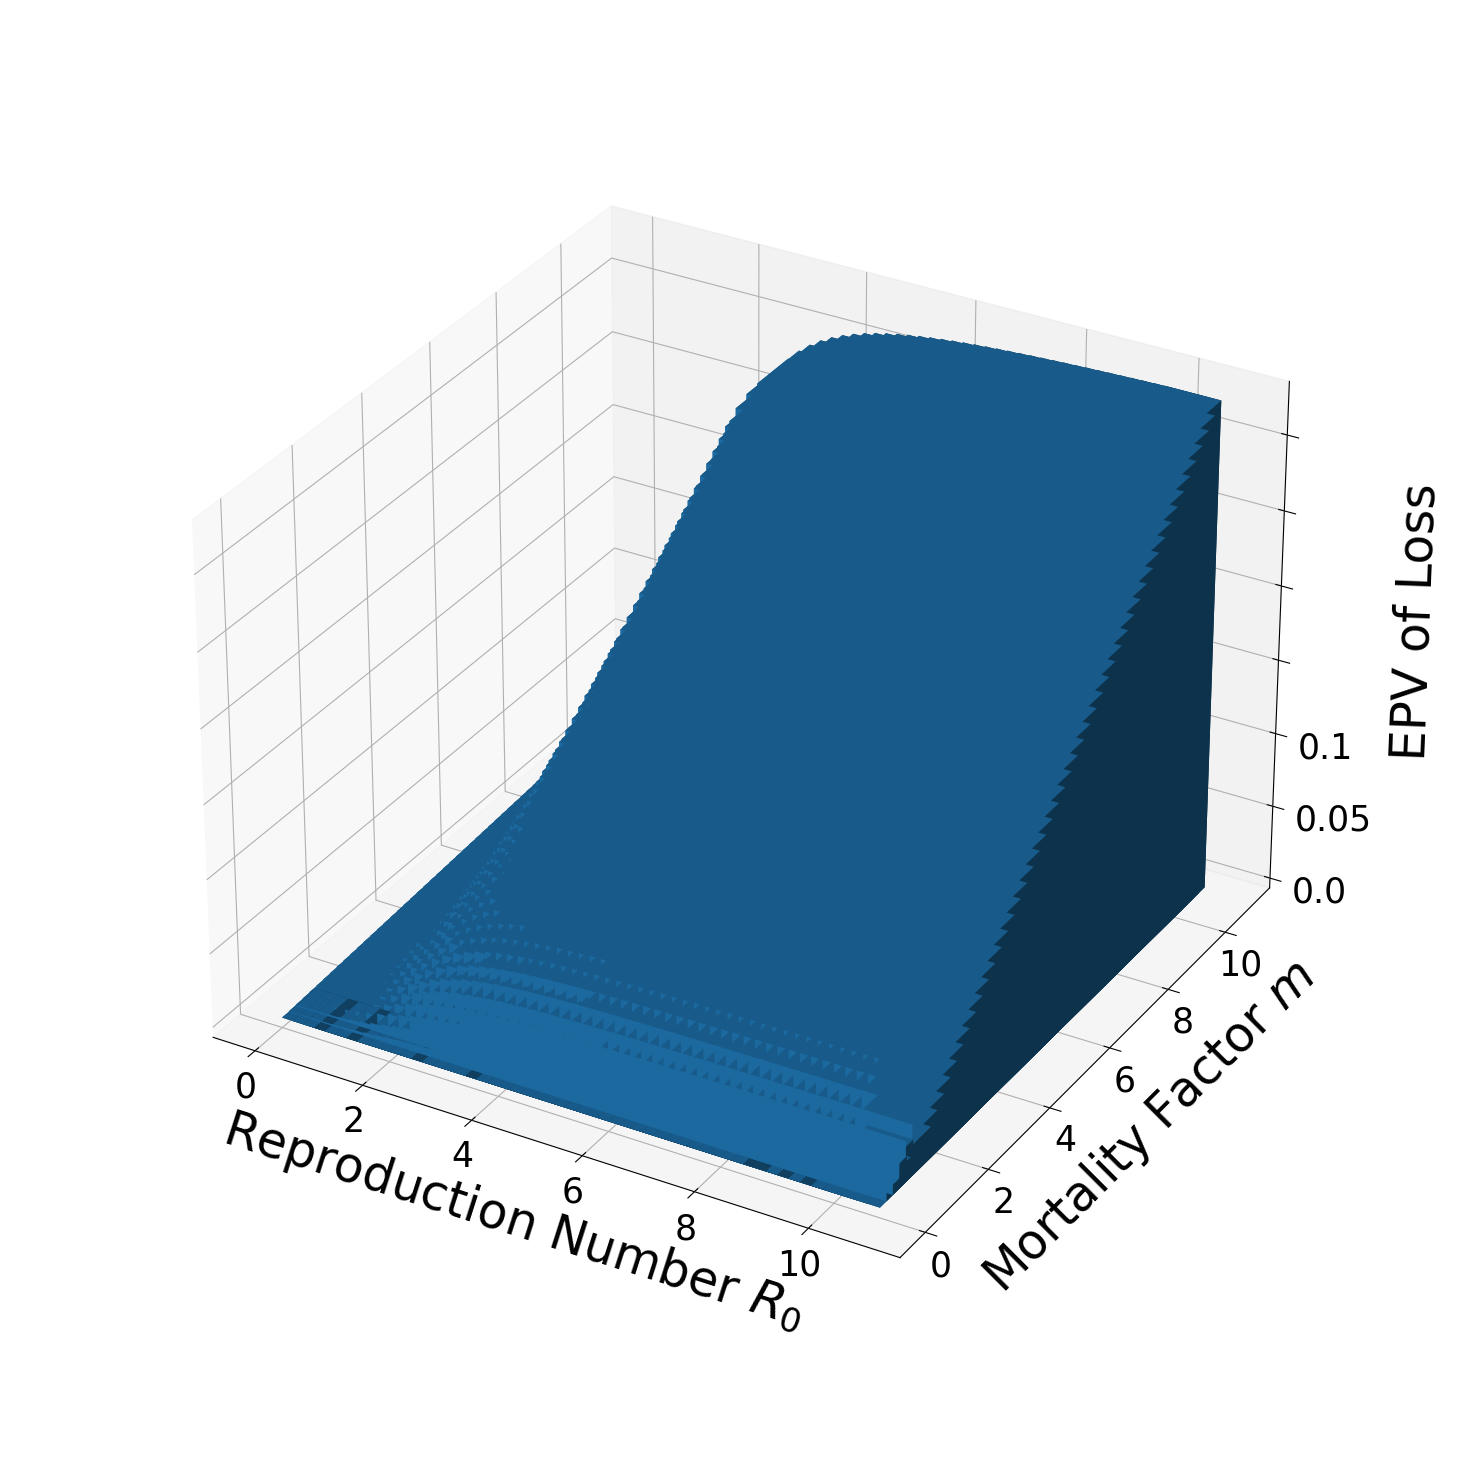

0.06563301776561646
0.06563301776561646


'print(y0[999,3])\ntpx = y0[:,3]\nmu_xt = mu*(1+mort_factor*y0[:,1])\ndiscount = np.exp(-delta *t)\nintegrand_ben = DB* tpx * mu_xt *discount\nintegrand_prem = P * tpx * discount\nEPV_ben = spi.trapezoid(integrand_ben,t)\nEPV_prem = spi.trapezoid(integrand_prem,t)\nprint(EPV_ben)\nprint(EPV_prem)\nprint("Loss of: ", EPV_ben + EPV_prem)'

In [3]:
mu = np.mean([7.4, 7.4, 7.6, 7.7, 7.6])/1000
#mort_factor = 3
delta = 0.05 # force of interest
ddt = lambda p,t: np.array([-mu*p[0], mu*p[0]])
#ic = np.array([0.95,0.05,0,1,0]) # S,I,R,Alive, dead
R0 = 4
DB = 1 #death benefit
P = -mu*DB #premium calculated using equiv principle, assuming no pandemic

def ddt(u,t,params):
    (R0, mort_factor) = params
    dudt = np.zeros(5)
    dudt[0] = -R0 * u[0]*u[1]
    dudt[1] = R0*u[0] * u[1] - u[1]
    dudt[2] = u[1]
    dudt[3] = -mu*(1+mort_factor*u[1])*u[3]
    dudt[4] = mu*(1+mort_factor*u[1])*u[3]
    return dudt

def find_EPV(r,m,infected = 0.05): #finds the EPV of loss for a given mort factor, reproduction number, % of pop initially infected 
  t = np.linspace(0,5,1000)
  R0 = r
  mort_factor = m
  ic = np.array([1-infected,infected,0,1,0])
  y0 = spi.odeint(lambda u,t: ddt(u,t,(R0,mort_factor)), ic, t)
  tpx = y0[:,3]
  mu_xt = mu*(1+mort_factor*y0[:,1])
  discount = np.exp(-delta *t)
  integrand_ben = DB* tpx * mu_xt *discount
  integrand_prem = P * tpx * discount
  EPV_ben = spi.trapezoid(integrand_ben,t)
  EPV_prem = spi.trapezoid(integrand_prem,t)
  return EPV_ben + EPV_prem
#making 3d graph of EPV for different R0, mort factors
granularity = 0.2
#print(find_EPV(4,6))
_R0_vals = np.arange(0,10,granularity)
#print(_R0_vals)
_mort_vals = np.arange(0,10,granularity)
_xx, _yy = np.meshgrid(_R0_vals, _mort_vals)

R0_vals, mort_vals = _xx.ravel(), _yy.ravel()

_top = np.zeros_like(_xx,dtype=float)

for i in range(len(_R0_vals)):
   for j in range(len(_mort_vals)):
      _top[j][i] = find_EPV(_R0_vals[i],_mort_vals[j])

top = _top.ravel()


bottom = np.zeros_like(top)
width = depth = 1
fig = plt.figure(figsize=(30, 30))
ax1 = fig.add_subplot(121, projection='3d')
ax1.bar3d(R0_vals, mort_vals, bottom, width, depth, top, shade=True)

ax1.set_xlabel("Reproduction Number $R_0$",fontsize=35)
ax1.set_ylabel("Mortality Factor $m$", fontsize=35)
ax1.set_zlabel("EPV of Loss",fontsize=35)
ax1.set_box_aspect(aspect=None, zoom=0.85) 
plt.subplots_adjust(bottom=0.04, top=0.05, left=0.04, right=0.05) 
#ax1.set_zticks(ticks,  minor=False)
ax1.set_zticklabels(ax1.get_zticks(), fontdict={'ha':'left'})
plt.tick_params(axis='y',labelsize=25)
plt.tick_params(axis='x',labelsize=25)
plt.tick_params(axis='z',labelsize=25)

plt.rcParams['xtick.major.pad'] = 4 # Default is usually 4
plt.rcParams['ytick.major.pad'] = 4
ax1.xaxis.labelpad = 25
ax1.yaxis.labelpad = 25
ax1.zaxis.labelpad = 50

plt.tight_layout()
plt.savefig("Paramsweep.pdf",bbox_inches='tight')

plt.show()
#double check working as expected
print(find_EPV(9.8,9.8))
print(_top[-1,-1])
'''print(y0[999,3])
tpx = y0[:,3]
mu_xt = mu*(1+mort_factor*y0[:,1])
discount = np.exp(-delta *t)
integrand_ben = DB* tpx * mu_xt *discount
integrand_prem = P * tpx * discount
EPV_ben = spi.trapezoid(integrand_ben,t)
EPV_prem = spi.trapezoid(integrand_prem,t)
print(EPV_ben)
print(EPV_prem)
print("Loss of: ", EPV_ben + EPV_prem)'''



(50, 50)
10


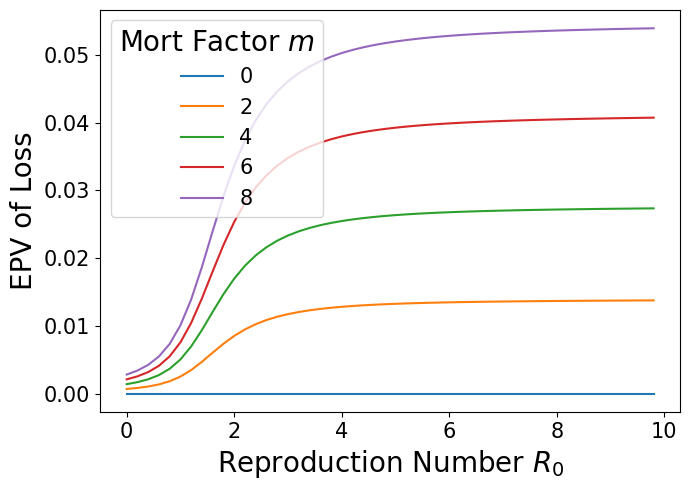

In [4]:
# Affect of R0 for fixed mortality factor

#TODO: add vertical marker for inflection point R0 * S = 1, do more analysis related to this inflection point
x = _R0_vals
print(_top.shape)
increment = _top.shape[0]//5
fig = plt.figure(figsize=(7, 5))

print(increment)
for i in range(5):

  y = _top[increment*i,:]
  l = str(i*2)
  plt.plot(x,y, label=l)

plt.tick_params(axis='y',labelsize=15)
plt.tick_params(axis='x',labelsize=15)
plt.legend(title="Mort Factor $m$",title_fontsize=20, fontsize = 15)
plt.xlabel("Reproduction Number $R_0$", fontsize=20)
plt.ylabel("EPV of Loss", fontsize=20)
plt.tight_layout()
plt.savefig("fixed_m_vary_r0.pdf")

plt.show()



(50, 50)
10


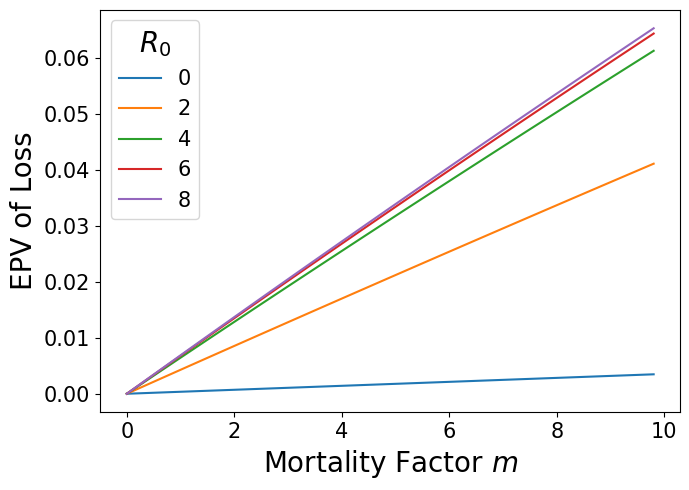

In [5]:
# Affect of Mortality factor for fixed R0

x = _mort_vals
print(_top.shape)
increment = _top.shape[0]//5
print(increment)
fig = plt.figure(figsize=(7, 5))

for i in range(5):

  y = _top[:,increment*i]
  l = str(i*2)
  plt.plot(x,y, label=l)


plt.tick_params(axis='y',labelsize=15)
plt.tick_params(axis='x',labelsize=15)
plt.legend(title="$R_0$",title_fontsize=20, fontsize = 15)
plt.xlabel("Mortality Factor $m$", fontsize=20)
plt.ylabel("EPV of Loss", fontsize=20)
plt.tight_layout()
plt.savefig("fixed_r0_vary_m.pdf")

plt.show()
